# Conference Paper Figures

All figures and numbers/metrics produced for power generation modeling in the IEEE paper "Deep Learning for Modeling and Dispatching Hybrid Wind Farm Power Generation"

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import jensenshannon

In [2]:
# load in historical data and model data for pyron and palouse wind farms
pyron = pd.read_csv('evaluation/rnn_models.csv')
palouse = pd.read_csv('evaluation/palouse_results.csv')

# set font for all graphs
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

In [3]:
# metric equation definitions

def rmse(power, preds):
    npower = (power - np.min(power)) / (np.max(power) - np.min(power))
    npreds = (preds - np.min(preds)) / (np.max(preds) - np.min(preds))
    return float(np.sqrt(np.mean((npower - npreds) ** 2)))

def cross_correlation(power, preds):
    npower = (power - np.min(power)) / (np.max(power) - np.min(power))
    npreds = (preds - np.min(preds)) / (np.max(preds) - np.min(preds))
    return float(np.corrcoef(npower, npreds)[0, 1])

def similarity(speeds, power, preds, bins=50): # power curve similarity
    H_true, _, _ = np.histogram2d(speeds, power, bins=bins)
    H_pred, _, _ = np.histogram2d(speeds, preds, bins=bins)
    H_true_norm = H_true / H_true.sum()
    H_pred_norm = H_pred / H_pred.sum()
    js_div = jensenshannon(H_true_norm.flatten(), H_pred_norm.flatten())
    similarity = 1 - js_div
    return float(similarity)

**Table VI:** metrics comparison of NQF-RNN models

In [4]:
# RMSE, cross correlation, power curve similarity
def calculate_metrics(model):
    return [np.round(rmse(pyron['power'], pyron[model]), 3),
            np.round(cross_correlation(pyron['power'], pyron[model]), 3),
            np.round(similarity(pyron['speed'], pyron['power'], pyron[model]), 3)]

print('RMSE, Cross Correlation, Power Curve Similarity')
print('12 hours:', calculate_metrics('rnn12'))
print('24 hours:', calculate_metrics('rnn24'))
print('72 hours:', calculate_metrics('rnn72'))
print('168 hours:', calculate_metrics('rnn168'))

RMSE, Cross Correlation, Power Curve Similarity
12 hours: [0.32, 0.464, 0.625]
24 hours: [0.228, 0.782, 0.75]
72 hours: [0.209, 0.756, 0.802]
168 hours: [0.189, 0.799, 0.803]


**Figure 4:** time series

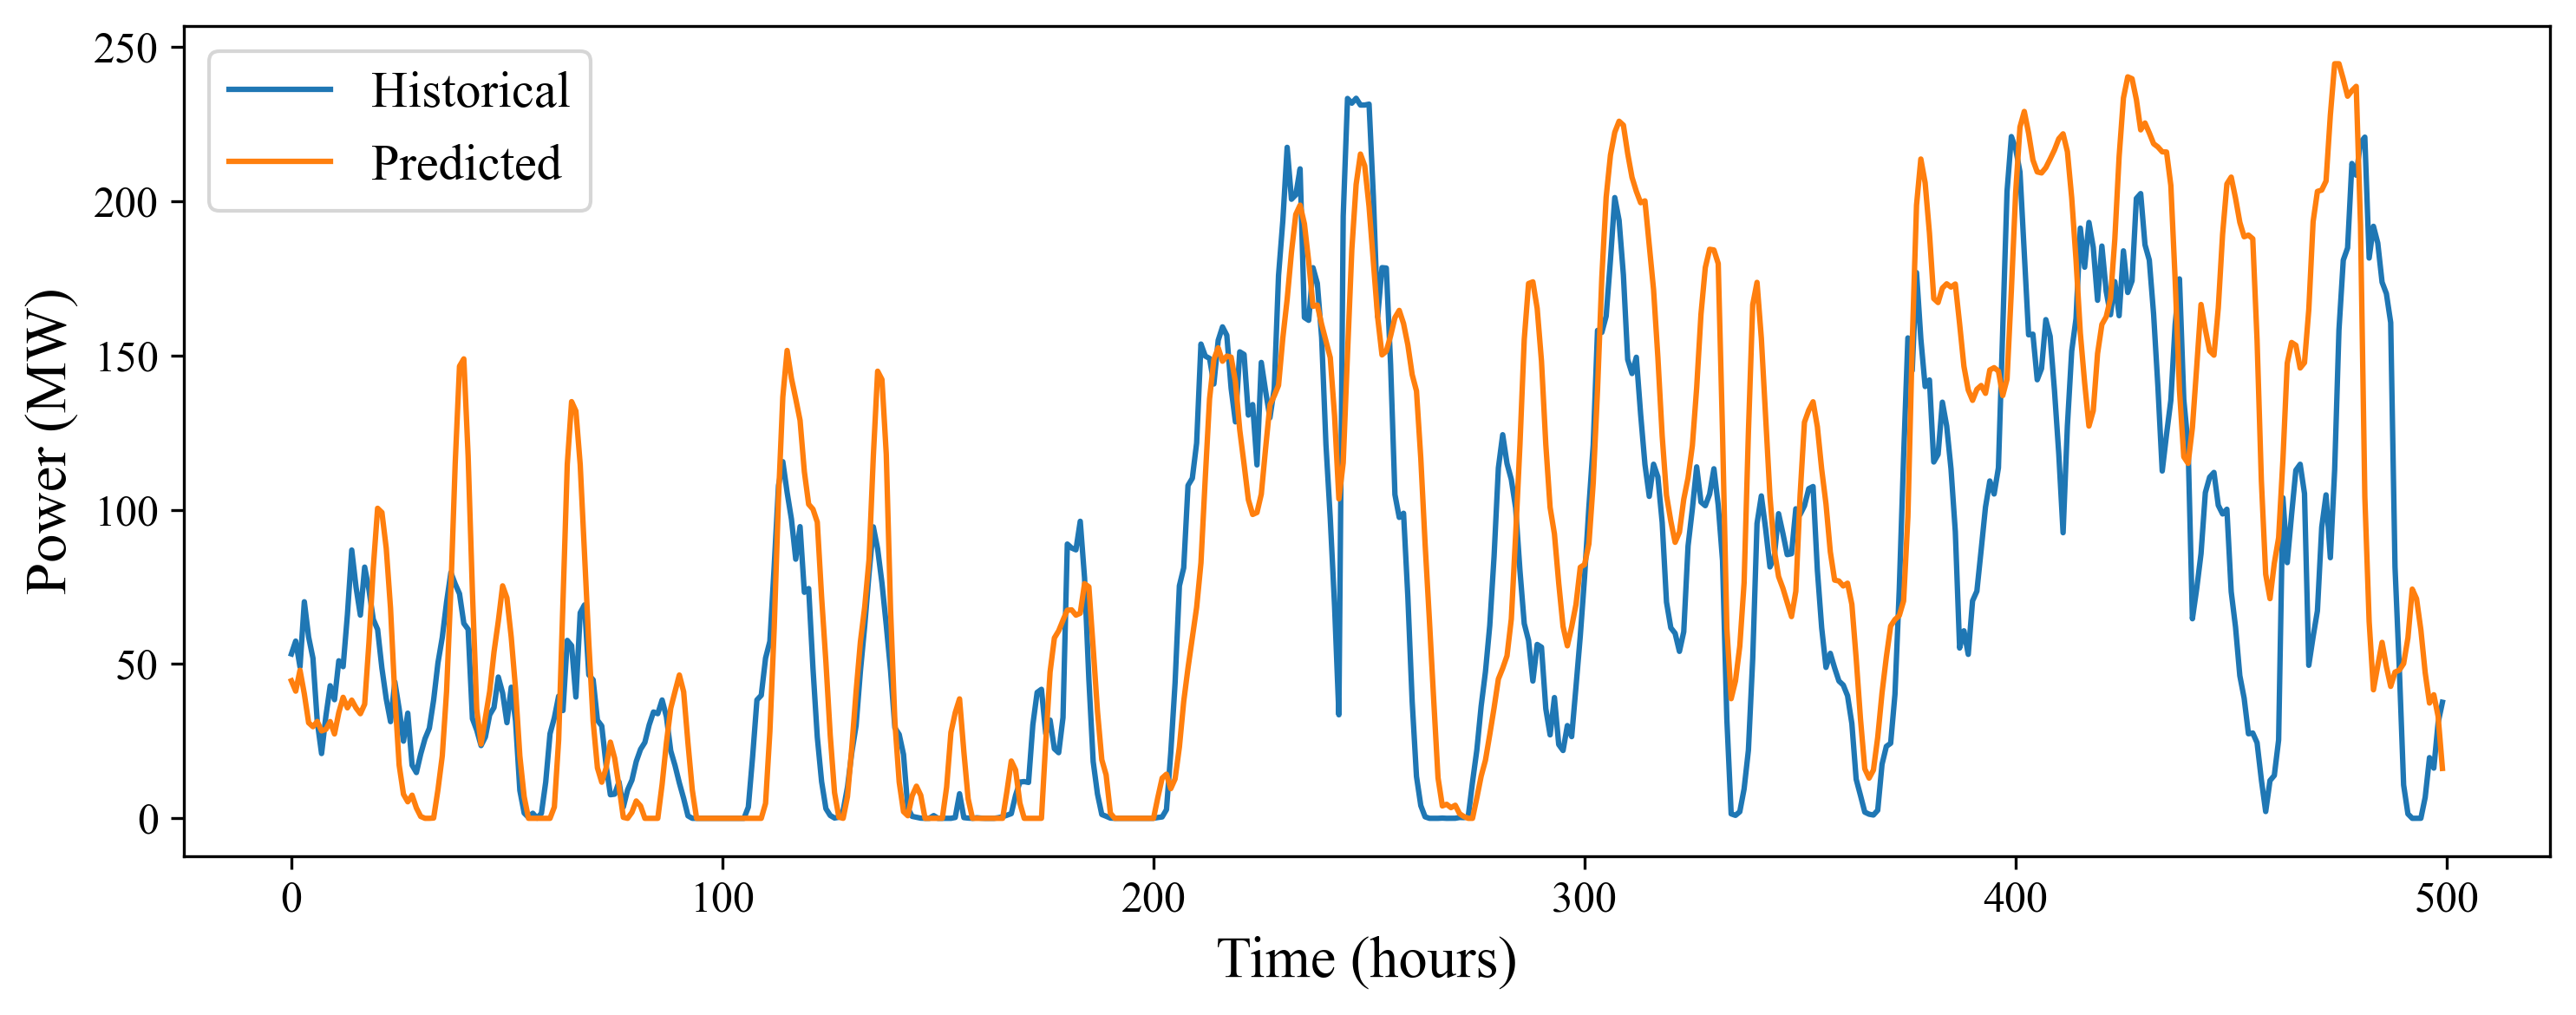

In [ ]:
# time series
plt.figure(figsize=(10, 4), dpi=300)
# random time period
plt.plot(pyron['power'][10200:10700].reset_index(drop=True), label='Historical')
plt.plot(pyron['rnn168'][10200:10700].reset_index(drop=True), label='Predicted')
plt.xlabel('Time (hours)', fontsize=16)
plt.ylabel('Power (MW)', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='upper left', fontsize=14)
plt.tight_layout()

**Figure 5:** power curve densities

/var/folders/ld/ry50f5bs3tzgqgpbq7z2_6pw0000gn/T/ipykernel_87248/1311699832.py:8: RuntimeWarning: divide by zero encountered in log
  vals_true = np.log(H_true.T)
/var/folders/ld/ry50f5bs3tzgqgpbq7z2_6pw0000gn/T/ipykernel_87248/1311699832.py:11: RuntimeWarning: divide by zero encountered in log
  vals_pred = np.log(H_pred.T)


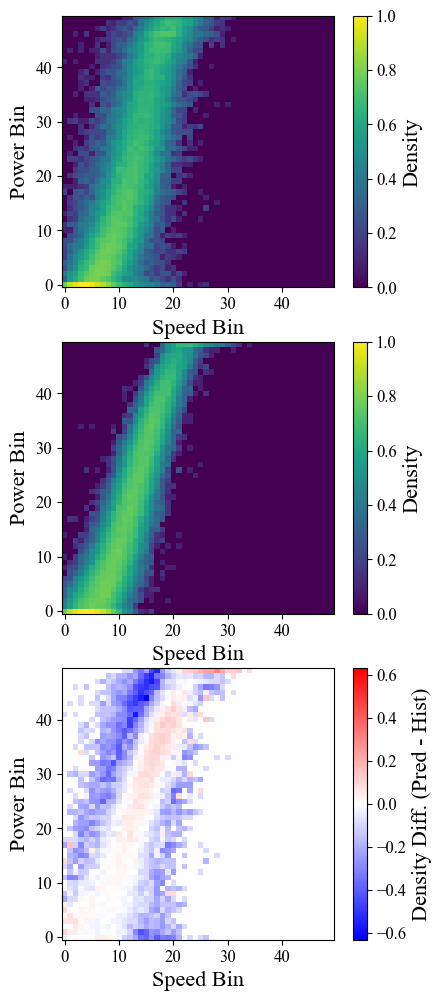

In [7]:
# calculate power curve densities
H_true, _, _ = np.histogram2d(pyron['speed'], pyron['power'], bins=50)
H_pred, _, _ = np.histogram2d(pyron['speed'], pyron['rnn168'], bins=50)
H_true_norm = H_true / H_true.sum()
H_pred_norm = H_pred / H_pred.sum()
js_div = jensenshannon(H_true_norm.flatten(), H_pred_norm.flatten())  # Value between 0 and 1
# log transform for better visualization
vals_true = np.log(H_true.T)
vals_true[np.isneginf(vals_true)] = 0
vals_true = vals_true / vals_true.max()
vals_pred = np.log(H_pred.T)
vals_pred[np.isneginf(vals_pred)] = 0
vals_pred = vals_pred / vals_pred.max()
diff = vals_pred - vals_true


# plot power curve densities (historical, predicted, difference)
fig, axs = plt.subplots(3, 1, figsize=(5, 12))

# historical power density
im0 = axs[0].imshow(vals_true, origin='lower', cmap='viridis')
axs[0].set_xlabel("Speed Bin", fontsize=16)
axs[0].set_ylabel("Power Bin", fontsize=16)
axs[0].tick_params(axis='both', which='major', labelsize=12)

# predicted power density
im1 = axs[1].imshow(vals_pred, origin='lower', cmap='viridis')
axs[1].set_xlabel("Speed Bin", fontsize=16)
axs[1].set_ylabel("Power Bin", fontsize=16)
axs[1].tick_params(axis='both', which='major', labelsize=12)

# difference in power density (predicted - historical)
im2 = axs[2].imshow(diff, origin='lower', cmap='bwr', vmin=-np.max(np.abs(diff)), vmax=np.max(np.abs(diff)))
axs[2].set_xlabel("Speed Bin", fontsize=16)
axs[2].set_ylabel("Power Bin", fontsize=16)
axs[2].tick_params(axis='both', which='major', labelsize=12)

cbar0 = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cbar0.set_label('Density', fontsize=16)
cbar0.ax.tick_params(labelsize=12)

cbar1 = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cbar1.set_label('Density', fontsize=16)
cbar1.ax.tick_params(labelsize=12)

cbar2 = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cbar2.set_label("Density Diff. (Pred - Hist)", fontsize=16)
cbar2.ax.tick_params(labelsize=12)

**Table VII:** comparison of NQF-RNN model to baselines

In [9]:
# RMSE, cross correlation, power curve similarity
def calculate_metrics_palouse(model):
    return [np.round(rmse(palouse['power'], palouse[model]), 3),
            np.round(cross_correlation(palouse['power'], palouse[model]), 3),
            np.round(similarity(palouse['speed'], palouse['power'], palouse[model]), 3)]

print('RMSE, Cross Correlation, Power Curve Similarity')
print('NWPDB:', calculate_metrics_palouse('nwpdb'))
print('PLUSWIND:', calculate_metrics_palouse('pluswind'))
print('NQF-RNN:', calculate_metrics_palouse('rnn_preds'))

RMSE, Cross Correlation, Power Curve Similarity
NWPDB: [0.23, 0.808, 0.577]
PLUSWIND: [0.199, 0.832, 0.395]
NQF-RNN: [0.18, 0.848, 0.686]
